# Laboratorio de regresión - 2

|                |   |
:----------------|---|
| **Nombre**     |  Diego Dueñas Martín |
| **Fecha**      |   2/2/2026|
| **Expediente** | 751426  |

## Regresión polinomial

Observa la siguiente gráfica.

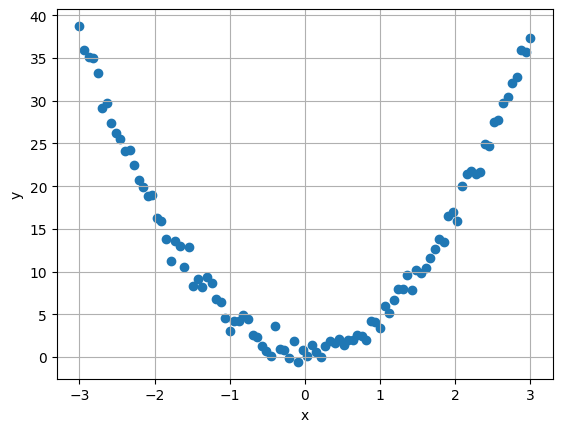

In [10]:


%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
x = np.linspace(-3, 3, 100); y = 1 + 4*x**2 + np.random.normal(0, 1, 100)
plt.figure(); plt.xlabel("x"); plt.ylabel("y")
plt.scatter(x, y); plt.grid()

Utiliza `sklearn` para realizar una regresión lineal simple ($\hat{y} = \hat{\beta_0} + \hat{\beta_1}x $)

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# modelo lineal simple
lr = LinearRegression()
lr.fit(x.reshape(-1, 1), y)

print("Regresión Lineal Simple:")
print(f"B0 (intercepto): {lr.intercept_:.4f}")
print(f"B1 (pendiente): {lr.coef_[0]:.4f}")
print(f"Ecuación: y = {lr.intercept_:.4f} + {lr.coef_[0]:.4f}x")

# Predicción con modelo lineal 
y_pred = lr.predict(x.reshape(-1, 1))

# Calcular R2
r2_simple = lr.score(x.reshape(-1, 1), y)
print(f"\nR2: {r2_simple:.4f}")

print(f"Varianza no explicada: {(1 - r2_simple) * 100:.2f}%")

# Basicamente un modelo simple no es adecuado para datos no lineales

Regresión Lineal Simple:
B0 (intercepto): 13.3022
B1 (pendiente): -0.0496
Ecuación: y = 13.3022 + -0.0496x

R2: 0.0001
Varianza no explicada: 99.99%


Crea una gráfica donde se muestren las observaciones como una nube de puntos y la línea que ajustaste con regresión. Calcula el métrico $R^2$.

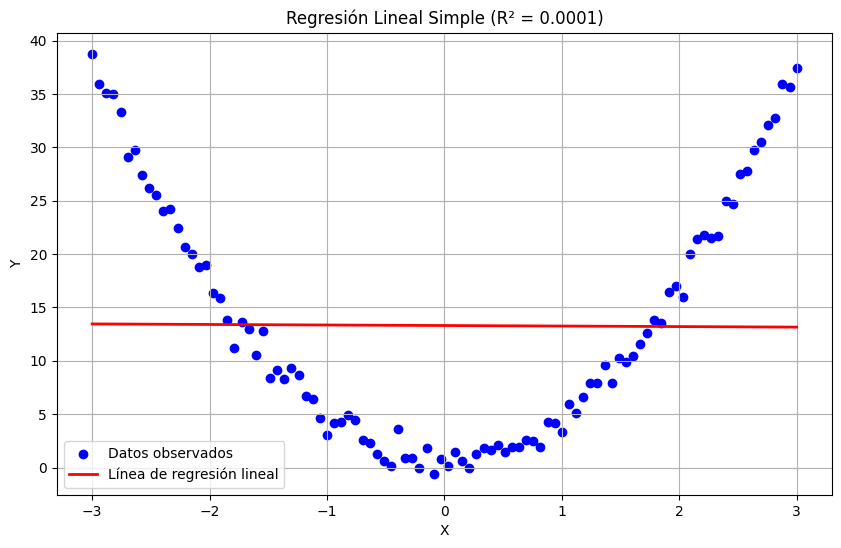

Varianza sin explicar: 99.99419654726077 %


In [ ]:
# Gráfica con observaciones y línea de regresión
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Datos observados')
plt.plot(x, y_pred, color='red', linewidth=2, label='Línea de regresión lineal')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Regresión Lineal Simple (R² = {r2_simple:.4f})')
plt.legend()
plt.grid(True)
plt.show()

Podemos ver que el ajuste no es correcto, pues parece que tiene un comportamiento cuadrático y estamos intentando ajustar una línea recta.

En lugar de hacer una regresión lineal simple, quizás podamos extender el modelo para que tenga varios factores dentro:

$$ Y = \beta_0 + \beta_1 X + \beta_2 X^2 + ... + \beta_p X^p + \epsilon$$

Ajusta un modelo cuadrático con `sklearn` ($\hat{y} = \hat{\beta_0} + \hat{\beta_1}x + \hat{\beta_1}x^2 $) y calcula su $R^2$.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Crear características polinomiales de grado 2
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2 = poly2.fit_transform(x.reshape(-1, 1))

# Ajustar modelo cuadrático
lr_quad = LinearRegression()
lr_quad.fit(X_poly2, y)

print("Regresión Cuadrática:")
print(f"Coeficientes: {lr_quad.coef_}")
print(f"Intercepto: {lr_quad.intercept_:.4f}")
print(f"Ecuación: y = {lr_quad.intercept_:.4f} + {lr_quad.coef_[0]:.4f}x + {lr_quad.coef_[1]:.4f}x^2")
# Predicción con modelo cuadrático
y_pred_quad = lr_quad.predict(X_poly2)

# Calcular R2
r2_quad = lr_quad.score(X_poly2, y)
print(f"\nR2 : {r2_quad:.4f}")
print(f"Porcentaje : {r2_quad * 100:.2f} %")
print(f"Varianza sin explicar: {(1 - r2_quad) * 100:.2f}%")

Regresión Cuadrática:
Coeficientes: [-0.04955448  4.14388884]
Intercepto: 0.6194
Ecuación: y = 0.6194 + -0.0496x + 4.1439x²

R2 : 0.9934
Porcentaje : 99.34 %
Varianza sin explicar: 0.66%


Crea una gráfica con las observaciones y la nueva curva que ajustaste.

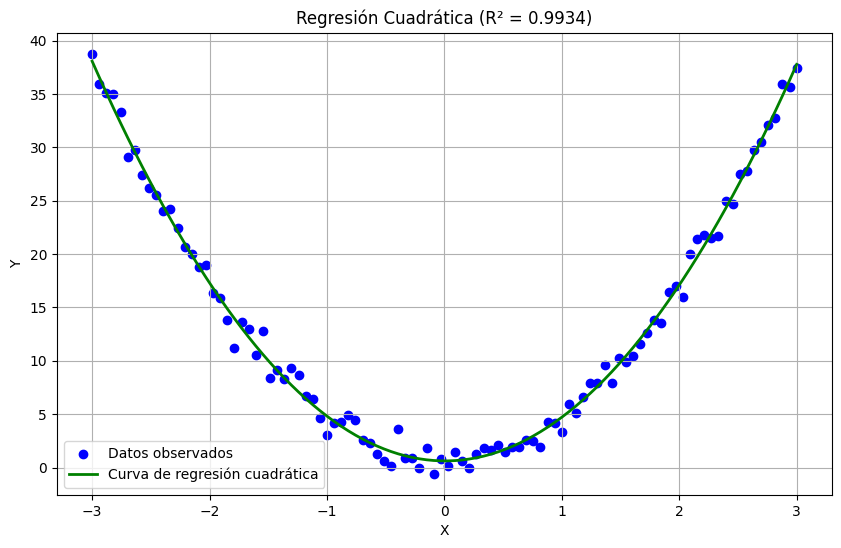

Varianza explicada por modelo cuadrático: 99.34%


In [ ]:
# Gráfica con curva cuadrática
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Datos observados')
plt.plot(x, y_pred_quad, color='green', linewidth=2, label='Curva de regresión cuadrática')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Regresión Cuadrática (R2 = {r2_quad:.4f})')
plt.legend()
plt.grid(True)
plt.show()
#El modelo cuadrático se ajusta mucho mejor a los datos.
# El R2 pasó de 0.0001 a .9934, una mejora.

Ajusta modelos de grados 3, 5, 7, 9, y 11. Calcula su $R^2$.

In [ ]:
# Ajustar modelos de diferentes grados
grados = [3, 5, 7, 9, 11]
modelos = {}
r2_scores = {}

for grado in grados:
    poly = PolynomialFeatures(degree=grado)
    X_poly = poly.fit_transform(x.reshape(-1, 1))
    
    lr = LinearRegression()
    lr.fit(X_poly, y)
    
    r2 = lr.score(X_poly, y)
    
    modelos[grado] = (lr, poly)
    r2_scores[grado] = r2
    
    print(f"Grado {grado}: R2 = {r2}")

#Aunque no lo parezca hay pequelos incrementos en R2 al aumentar el grado del polinomio, pero no son significativos.

Grado 3: R2 = 0.9934129585186598
Grado 5: R2 = 0.9934954953676421
Grado 7: R2 = 0.9935089341876935
Grado 9: R2 = 0.9935141799662259
Grado 11: R2 = 0.9935338704150221


Crea una gráfica por cada modelo con las observaciones y su curva.

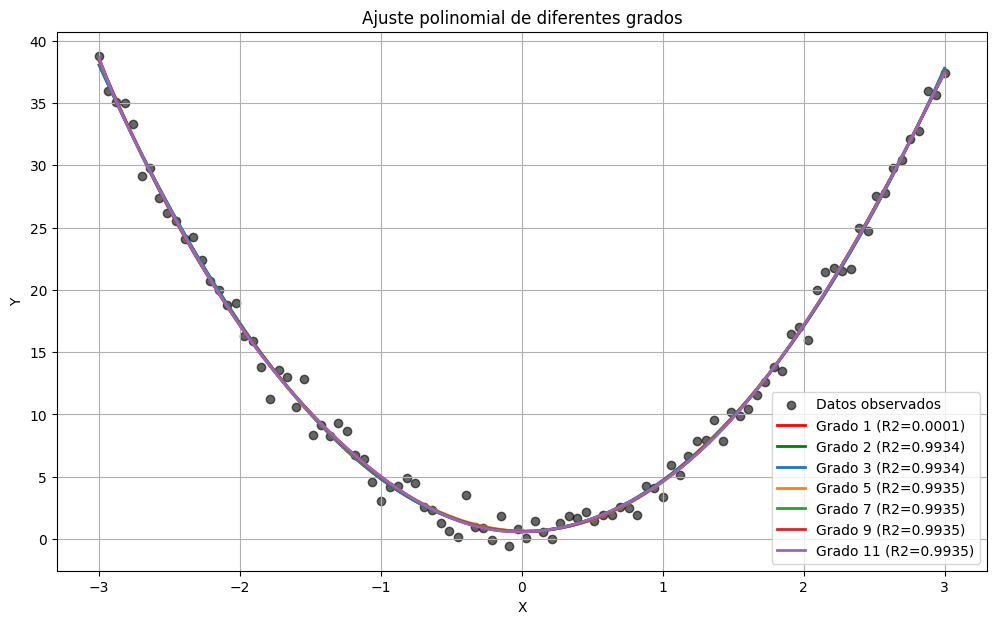

In [37]:
plt.figure(figsize=(12, 7))
plt.scatter(x, y, color='black', alpha=0.6, label='Datos observados')

# Grado 1 (lineal)
plt.plot(x, y_pred, color='red', linewidth=2, label=f'Grado 1 (R2={r2_simple:.4f})')

# Grado 2 (cuadrático)
plt.plot(x, y_pred_quad, color='green', linewidth=2, label=f'Grado 2 (R2={r2_quad:.4f})')

# Grados superiores
for grado in grados:
    lr, poly = modelos[grado]
    y_pred_g = lr.predict(poly.transform(x.reshape(-1, 1)))
    plt.plot(x, y_pred_g, linewidth=2, label=f'Grado {grado} (R2={r2_scores[grado]:.4f})')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Ajuste polinomial de diferentes grados')
plt.legend()
plt.grid(True)
plt.show()

#poca necesidad de usar grados mayores a 2, ya que la mejora en R2 es diminuta.


**¿Cuál modelo consideras que es mejor? ¿Por qué?**

In [ ]:
#Sin duda alguna el modelo cuadratico es el mejor debido a que se ajusta perfectamente a los datos.
#Aparte de que este explica los datos en un 99.34%

Recuerda que una de las metas de ajustar modelos es para poder interpolar y extrapolar. Los datos que tenemos mantienen $x \in [-3, 3]$. ¿Qué pasaría si quisiéramos saber el valor de $y$ cuando $x=5$?

Calcula la predicción $\hat{y}$ para todos los modelos creados (grados 2, 3, 5, 7, 9, y 11).

In [43]:
# Predicciones para x = 5
x_pred = np.array([[5]])

print("Predicciones x = 5")

# Predicción lineal (usa el modelo entrenado en grado 1)
y_pred_lin = LinearRegression().fit(x.reshape(-1, 1), y).predict(x_pred)
print(f"nModelo Lineal (grado 1):")
print(f"  y(5) = {y_pred_lin[0]:.4f}")

# Predicción cuadrática
X_pred_quad = poly2.transform(x_pred)
y_pred_q = lr_quad.predict(X_pred_quad)
print(f"Modelo Cuadrático (grado 2):")
print(f"  y(5) = {y_pred_q[0]:.4f}")

# Predicciones para grados superiores
for grado in grados:
    lr_g, poly_g = modelos[grado]
    X_pred_poly = poly_g.transform(x_pred)
    y_pred_g = lr_g.predict(X_pred_poly)
    print(f"Modelo de Grado {grado}:")
    print(f"  y(5) = {y_pred_g[0]:.4f}")

Predicciones x = 5
nModelo Lineal (grado 1):
  y(5) = 13.0545
Modelo Cuadrático (grado 2):
  y(5) = 103.9689
Modelo de Grado 3:
  y(5) = 104.2523
Modelo de Grado 5:
  y(5) = 84.5990
Modelo de Grado 7:
  y(5) = 33.7432
Modelo de Grado 9:
  y(5) = 215.7364
Modelo de Grado 11:
  y(5) = -5265.3443


¿Cuál modelo crees que sea mejor?

In [ ]:
#Pues sinnceramente n cuestion de creer, me atrevo a decir que el modelo mientras no sea el lineal
#esta bien, debido a que los otros modelos si logran ajustarse a los datos, y el lineal no.
#Ademas de que los otros modelos explican gran porcentaje de la varianza, todos teniendo un inntervalo de confianza


## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3